# CO2 Emissions Forecasting (R3)

This notebook implements **R3 only** from `Fix.md`:
1. Time-aware forecasting setup
2. Feature engineering (lags and rolling trends)
3. Baselines (Linear, Ridge, Lasso)
4. Tree models (Random Forest, XGBoost if available)
5. Deep learning (MLP, LSTM if TensorFlow is available)
6. Optional Hugging Face pretrained model check
7. Ensemble and final comparison


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# -----------------------------
# Runtime / CUDA setup (first)
# -----------------------------
# We detect CUDA as early as possible so later model cells can decide whether
# to use GPU backends when supported.
HAS_TORCH = False
HAS_CUDA = False
CUDA_DEVICE_NAME = 'None'
DEVICE = 'cpu'

try:
    import torch

    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
    DEVICE = 'cuda' if HAS_CUDA else 'cpu'
    if HAS_CUDA:
        CUDA_DEVICE_NAME = torch.cuda.get_device_name(0)
except Exception as e:
    torch = None
    print('PyTorch not available:', e)

print('PyTorch available:', HAS_TORCH)
print('CUDA available:', HAS_CUDA)
print('CUDA device:', CUDA_DEVICE_NAME)
print('Default torch device:', DEVICE)

# TensorFlow is optional; if present, it can also use CUDA automatically.
HAS_TF = False
TF_BUILT_WITH_CUDA = False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    HAS_TF = True
    TF_BUILT_WITH_CUDA = bool(tf.test.is_built_with_cuda())
    tf_gpus = tf.config.list_physical_devices('GPU')
    print('TensorFlow built with CUDA:', TF_BUILT_WITH_CUDA)
    print('TensorFlow GPUs detected:', tf_gpus)

    # Keep VRAM allocation dynamic instead of grabbing all memory at startup.
    for gpu in tf_gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    if len(tf_gpus) == 0:
        print('TensorFlow will run on CPU (no TF-visible GPU).')
except Exception as e:
    tf = None
    keras = None
    layers = None
    print('TensorFlow not available:', e)


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Paths are aligned with the existing project convention.
DATA_PATH = Path('cleaned_co2_data_20vars.csv')
OUTPUT_DIR = Path('output_r3')
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)

TARGET = 'co2_per_capita'
ID_COLS = ['country', 'year', 'iso_code']

BASE_FEATURES = [
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'energy_per_gdp',
]

RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)


def plot_pred_vs_actual(y_true, y_pred, model_name, suffix='test'):
    """
    Plot predicted vs actual values for one model and save to disk.

    Why this helper exists:
    - We want a consistent diagnostic plot after each model block.
    - Using one helper avoids copy-paste and keeps figure style uniform.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_true, y_pred, alpha=0.35)
    mn, mx = float(np.nanmin(y_true)), float(np.nanmax(y_true))
    plt.plot([mn, mx], [mn, mx], 'r--', lw=1)
    plt.xlabel('Actual co2_per_capita')
    plt.ylabel(f'Predicted ({model_name})')
    plt.title(f'{model_name}: Actual vs Predicted ({suffix})')
    plt.tight_layout()

    safe_name = model_name.lower().replace('(', '_').replace(')', '_').replace('+', '_').replace(' ', '_')
    out_path = OUTPUT_DIR / 'figures' / f'r3_{safe_name}_{suffix}_pred_vs_actual.png'
    plt.savefig(out_path, dpi=140)
    plt.show()


PyTorch available: True
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5060 Laptop GPU
Default torch device: cuda


I0000 00:00:1776701860.809322   16244 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776701860.881665   16244 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776701862.847762   16244 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow built with CUDA: True
TensorFlow GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776701863.492902   16244 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 1. Load data and build time-aware features


In [2]:
# Read and sort first so all lag features are computed in the correct temporal order.
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['country', 'year']).reset_index(drop=True)

# Keep only available base features to avoid hard failures if schema changed.
base_features = [c for c in BASE_FEATURES if c in df.columns]
print('Data shape:', df.shape)
print('Year range:', df['year'].min(), '-', df['year'].max())
print('Base features used:', len(base_features))

# Country-wise lag features directly follow the R3 requirement in Fix.md.
g = df.groupby('country')
df['co2_lag1'] = g[TARGET].shift(1)
df['co2_lag3'] = g[TARGET].shift(3)

if 'gdp' in df.columns:
    df['gdp_lag1'] = g['gdp'].shift(1)
if 'energy_per_capita' in df.columns:
    df['energy_lag1'] = g['energy_per_capita'].shift(1)

# Rolling trend features summarize short-term history and reduce noise.
# IMPORTANT: .shift(1) is applied *after* .mean() so that the feature for year t
# is built from years t-3..t-1 (3-year window) or t-5..t-1 (5-year window).
# Without shift(1) the rolling mean for year t would include co2_per_capita at
# year t itself — the same value we are trying to predict — which is direct leakage.
df['co2_roll3_mean'] = (
    g[TARGET].rolling(window=3, min_periods=2).mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)
df['co2_roll5_mean'] = (
    g[TARGET].rolling(window=5, min_periods=3).mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

# Names of every engineered feature created above (all already shifted — no leakage).
engineered_features = [
    c for c in [
        'co2_lag1', 'co2_lag3',
        'gdp_lag1', 'energy_lag1',
        'co2_roll3_mean', 'co2_roll5_mean',
    ]
    if c in df.columns
]

# CRITICAL leakage guard:
# feature_cols is built ONLY from base_features (safe covariates) plus the engineered
# lag/rolling features above — NOT from df.columns wholesale.
# Using df.columns would silently pull in co2, total_ghg, coal_co2, oil_co2,
# gas_co2, consumption_co2, which are components or near-duplicates of the target
# co2_per_capita and constitute direct data leakage.
feature_cols = [c for c in base_features + engineered_features if c in df.columns]

# First rows per country have NaN due to lag/rolling by design; drop only after feature creation.
model_df = df[ID_COLS + [TARGET] + feature_cols].dropna().copy()

print('Safe base features:', base_features)
print('Engineered features:', engineered_features)
print('Total feature count:', len(feature_cols))
print('Modeling rows after lag/rolling:', model_df.shape)


Data shape: (2640, 20)
Year range: 1990 - 2022
Base features used: 5
Safe base features: ['population', 'gdp', 'primary_energy_consumption', 'energy_per_capita', 'energy_per_gdp']
Engineered features: ['co2_lag1', 'co2_lag3', 'gdp_lag1', 'energy_lag1', 'co2_roll3_mean', 'co2_roll5_mean']
Total feature count: 11
Modeling rows after lag/rolling: (2368, 15)


In [3]:
# Time-based split (not random) to respect forecasting chronology.
train = model_df[(model_df['year'] >= 1990) & (model_df['year'] <= 2015)].copy()
val = model_df[(model_df['year'] >= 2016) & (model_df['year'] <= 2019)].copy()
test = model_df[(model_df['year'] >= 2020) & (model_df['year'] <= 2022)].copy()

predictor_cols = [c for c in feature_cols if c in train.columns]

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')
print('Predictor count:', len(predictor_cols))

# Standardize for linear models and neural networks.
scaler = StandardScaler()
X_train = scaler.fit_transform(train[predictor_cols])
X_val = scaler.transform(val[predictor_cols])
X_test = scaler.transform(test[predictor_cols])

y_train = train[TARGET].to_numpy()
y_val = val[TARGET].to_numpy()
y_test = test[TARGET].to_numpy()

# Tree models often work well without scaling, so we keep raw matrices too.
X_train_raw = train[predictor_cols].to_numpy()
X_val_raw = val[predictor_cols].to_numpy()
X_test_raw = test[predictor_cols].to_numpy()


Train: 1756 | Val: 346 | Test: 266
Predictor count: 11


In [4]:
def evaluate(y_true, y_pred):
    """
    Compute the full regression metric set used across all R3 models.

    What this function does:
    1) Converts inputs to numpy arrays for consistent math behavior.
    2) Computes RMSE to penalize larger errors more strongly.
    3) Computes MAE for easy-to-interpret average absolute error.
    4) Computes R2 to measure explained variance quality.
    5) Computes MAPE with zero-safe handling to avoid divide-by-zero crashes.

    Returning a single dictionary keeps every model comparison table consistent.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # MAPE can explode when y_true is 0; we replace near-zero denominators with NaN
    # so they are ignored in the average rather than causing inf values.
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'MAPE': float(mape) if not np.isnan(mape) else np.nan,
    }


## 2. Baseline models (Linear, Ridge, Lasso)


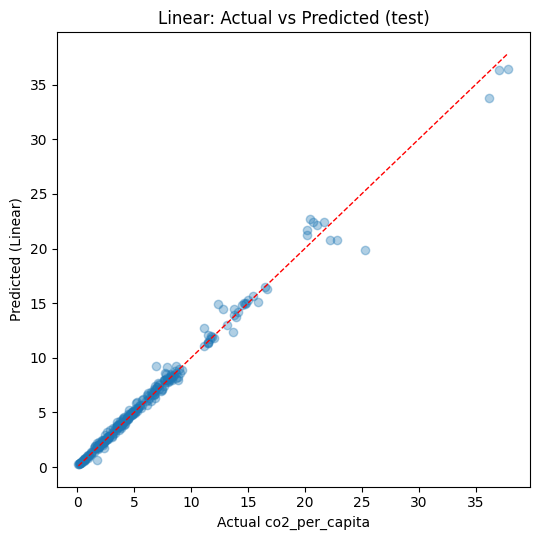

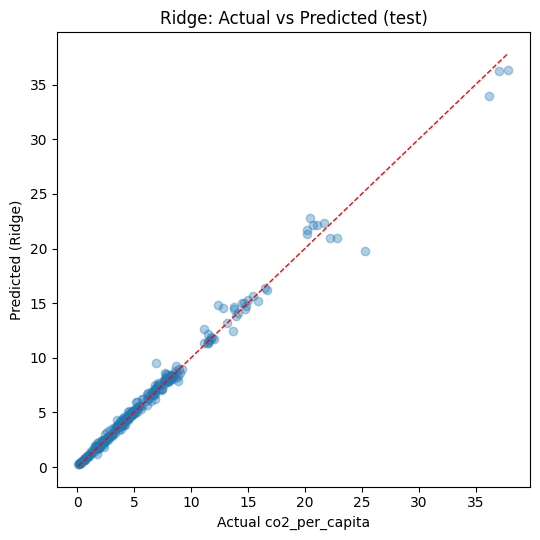

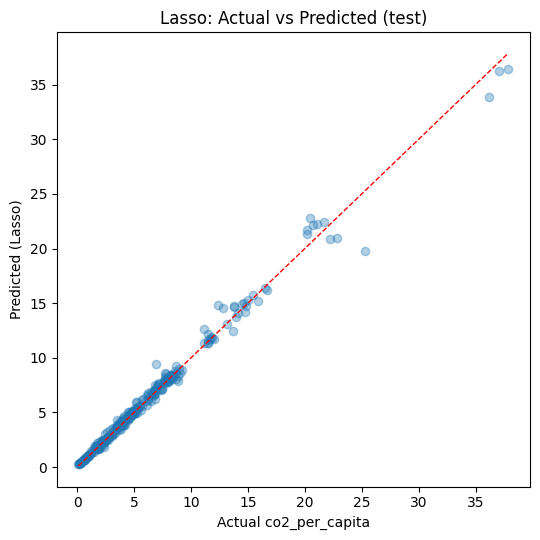

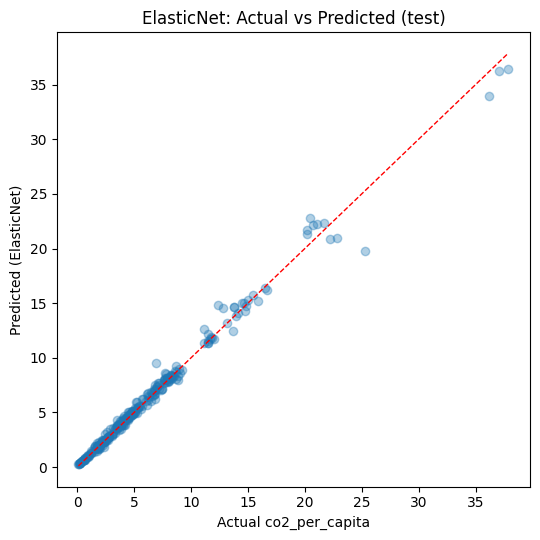

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Linear,0.520273,0.249200,0.992682,6.058098,0.600118,0.307198,0.989085,7.767339
1,Ridge,0.512608,0.246988,0.992897,6.364243,0.598860,0.312562,0.989130,8.073940
2,Lasso,0.512520,0.245474,0.992899,6.303848,0.601512,0.316972,0.989034,8.070013
3,ElasticNet,0.510379,0.247459,0.992958,6.425369,0.599602,0.317169,0.989103,8.205573


In [5]:
preds = {}   # model_name -> np.array of test predictions (all aligned to y_test)
results = [] # list of metric dicts, one per model


def add_result(row):
    """
    Upsert a result row by model name.

    Why this matters:
    - Without this, re-running any cell without a full kernel restart
      appends duplicate rows (e.g. two TimesFM rows) which corrupts the
      final comparison table and ruins the ensemble selection.
    - Using upsert ensures each model always has exactly one entry.
    """
    global results
    results = [r for r in results if r.get('Model') != row.get('Model')]
    results.append(row)


baseline_models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000),
    # ElasticNet combines L1 (Lasso) and L2 (Ridge) regularization.
    # l1_ratio=0.5 balances both penalties equally.
    # It is more robust than either alone when predictors are correlated.
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
}

# Note: sklearn linear-family models are CPU implementations.
# They do not have native CUDA training paths.
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)
    preds[name] = pred_test

    row = {'Model': name}
    row.update({f'Val_{k}': v for k, v in evaluate(y_val, pred_val).items()})
    row.update({f'Test_{k}': v for k, v in evaluate(y_test, pred_test).items()})
    add_result(row)

    plot_pred_vs_actual(y_test, pred_test, name, suffix='test')

pd.DataFrame(results)


## 3. Tree-based models (Random Forest, XGBoost)


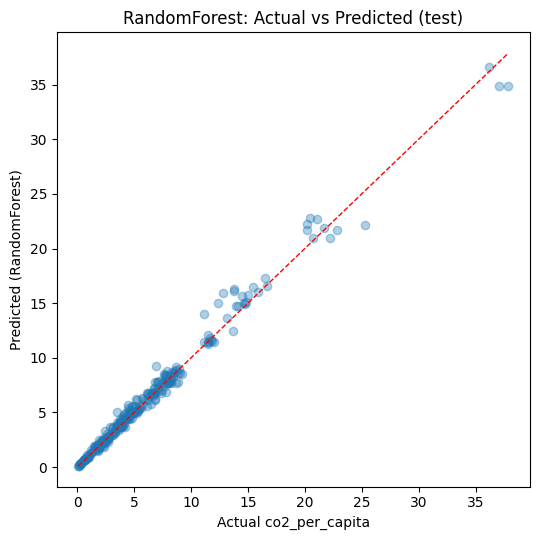

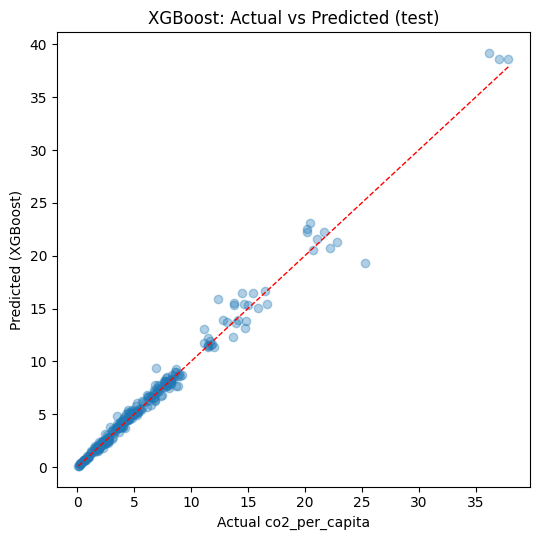

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Linear,0.520273,0.249200,0.992682,6.058098,0.600118,0.307198,0.989085,7.767339
1,Ridge,0.512608,0.246988,0.992897,6.364243,0.598860,0.312562,0.989130,8.073940
2,Lasso,0.512520,0.245474,0.992899,6.303848,0.601512,0.316972,0.989034,8.070013
3,ElasticNet,0.510379,0.247459,0.992958,6.425369,0.599602,0.317169,0.989103,8.205573
4,RandomForest,0.618153,0.276880,0.989670,4.894583,0.682307,0.400797,0.985890,7.515749
5,XGBoost,0.522824,0.271946,0.992611,5.150258,0.724730,0.393283,0.984081,7.459139


In [6]:
# Random Forest is a robust non-linear baseline.
# Note: sklearn RandomForest is CPU-only.
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_raw, y_train)
preds['RandomForest'] = rf.predict(X_test_raw)

row_rf = {'Model': 'RandomForest'}
row_rf.update({f'Val_{k}': v for k, v in evaluate(y_val, rf.predict(X_val_raw)).items()})
row_rf.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['RandomForest']).items()})
add_result(row_rf)
plot_pred_vs_actual(y_test, preds['RandomForest'], 'RandomForest', suffix='test')

# XGBoost can use CUDA if available.
try:
    from xgboost import XGBRegressor

    xgb_kwargs = {
        'n_estimators': 500,
        'learning_rate': 0.03,
        'max_depth': 6,
        'subsample': 0.9,
        'colsample_bytree': 0.8,
        'objective': 'reg:squarederror',
        'random_state': 42,
    }

    # Recent xgboost versions support device='cuda'.
    # Older ones may require tree_method='gpu_hist'.
    if HAS_CUDA:
        xgb_kwargs.update({'device': 'cuda', 'tree_method': 'hist'})

    xgb = XGBRegressor(**xgb_kwargs)
    xgb.fit(X_train_raw, y_train)
    preds['XGBoost'] = xgb.predict(X_test_raw)

    row_xgb = {'Model': 'XGBoost'}
    row_xgb.update({f'Val_{k}': v for k, v in evaluate(y_val, xgb.predict(X_val_raw)).items()})
    row_xgb.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['XGBoost']).items()})
    add_result(row_xgb)
    plot_pred_vs_actual(y_test, preds['XGBoost'], 'XGBoost', suffix='test')
except Exception as e:
    print('XGBoost skipped:', e)

pd.DataFrame(results)


## 4. Neural network baseline (MLP)


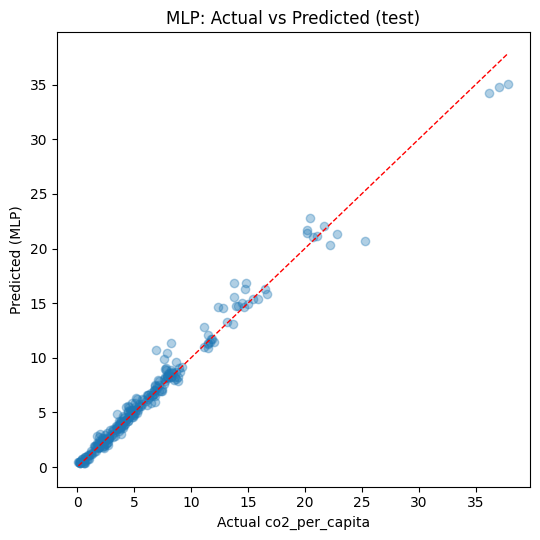

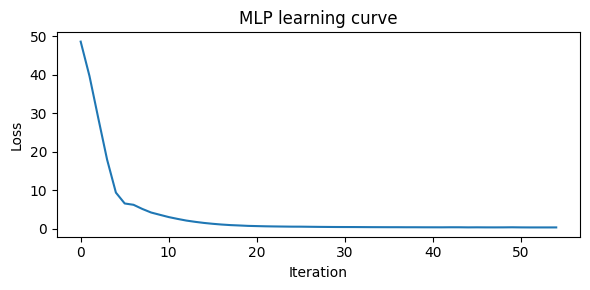

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Linear,0.520273,0.249200,0.992682,6.058098,0.600118,0.307198,0.989085,7.767339
1,Ridge,0.512608,0.246988,0.992897,6.364243,0.598860,0.312562,0.989130,8.073940
2,Lasso,0.512520,0.245474,0.992899,6.303848,0.601512,0.316972,0.989034,8.070013
3,ElasticNet,0.510379,0.247459,0.992958,6.425369,0.599602,0.317169,0.989103,8.205573
4,RandomForest,0.618153,0.276880,0.989670,4.894583,0.682307,0.400797,0.985890,7.515749
5,XGBoost,0.522824,0.271946,0.992611,5.150258,0.724730,0.393283,0.984081,7.459139
6,MLP,0.611707,0.369143,0.989885,10.684684,0.782457,0.466246,0.981444,14.045841


In [7]:
# MLP provides a non-linear baseline without sequence structure.
# Note: sklearn's MLPRegressor is CPU-only.
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
mlp.fit(X_train, y_train)

preds['MLP'] = mlp.predict(X_test)
row_mlp = {'Model': 'MLP'}
row_mlp.update({f'Val_{k}': v for k, v in evaluate(y_val, mlp.predict(X_val)).items()})
row_mlp.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['MLP']).items()})
add_result(row_mlp)

plot_pred_vs_actual(y_test, preds['MLP'], 'MLP', suffix='test')

if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(6, 3))
    plt.plot(mlp.loss_curve_)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('MLP learning curve')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / 'r3_mlp_learning_curve.png', dpi=150)
    plt.show()

pd.DataFrame(results)


## 5. Sequence model (LSTM)


LSTM train sequences: (1666, 5, 11)
LSTM test sequences: (256, 5, 11)


W0000 00:00:1776701871.526153   16244 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776701871.560859   16244 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5126 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1776701874.896729   16427 cuda_dnn.cc:461] Loaded cuDNN version 91002


LSTM val RMSE: 0.8289


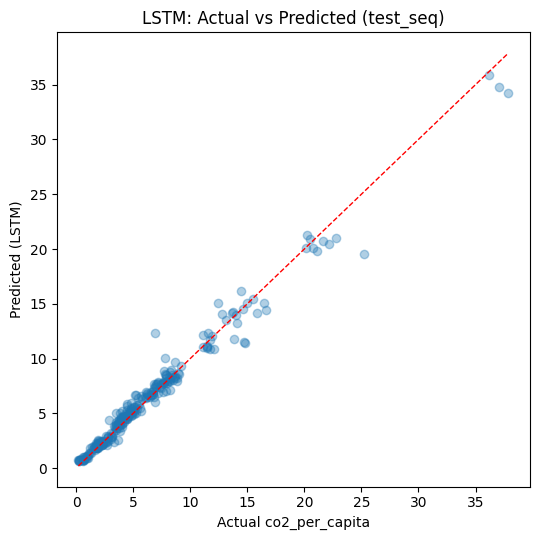

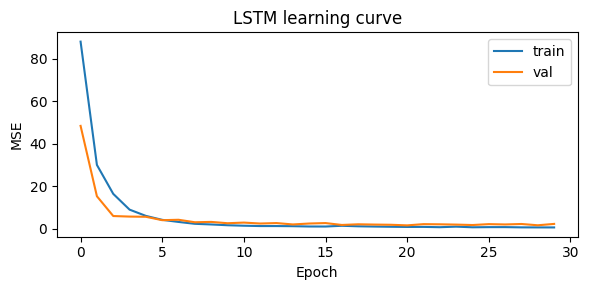

In [8]:
SEQ_LEN = 5

def build_sequences(frame, pred_cols, target_col, seq_len=5):
    """
    Convert panel data into LSTM-ready sliding windows.

    For each country independently:
    - X[i] contains `seq_len` historical timesteps
    - y[i] is the target at the next timestep
    """
    X_list, y_list = [], []
    for _, g in frame.sort_values(['country', 'year']).groupby('country'):
        g = g.sort_values('year')
        arr_x = g[pred_cols].to_numpy()
        arr_y = g[target_col].to_numpy()

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            X_list.append(arr_x[i - seq_len:i])
            y_list.append(arr_y[i])

    return np.array(X_list), np.array(y_list)


def build_test_sequences_with_history(history_frame, test_frame, pred_cols, target_col, seq_len=5):
    """
    Build test sequences using pre-test history as context.

    Why this is required:
    - If test only has years 2020-2022 and seq_len=5, test-alone has no windows.
    - We concatenate each country's history + test rows, then only keep windows
      whose target year is in the true test period.
    """
    X_list, y_list = [], []
    test_years = set(test_frame['year'].unique())
    combined = pd.concat([history_frame, test_frame], ignore_index=True)

    for _, g in combined.sort_values(['country', 'year']).groupby('country'):
        g = g.sort_values('year')
        arr_x = g[pred_cols].to_numpy()
        arr_y = g[target_col].to_numpy()
        arr_year = g['year'].to_numpy()

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            # Keep only labels that belong to test years.
            if arr_year[i] in test_years:
                X_list.append(arr_x[i - seq_len:i])
                y_list.append(arr_y[i])

    return np.array(X_list), np.array(y_list)


# Build a LSTM-specific scaler fitted on train ONLY.
# We must NOT reuse or refit the global `scaler` here because:
#   1. fit_transform on train+val would leak val statistics into the scale
#      parameters used for ALL models that depend on the global scaler.
#   2. Mutating the global scaler after Cell 4 would silently corrupt X_train,
#      X_val, X_test if any earlier cell is re-run.
# Using a separate local scaler, fitted exclusively on `train`, keeps the
# split boundary clean while still allowing the LSTM to train on train+val rows.
lstm_scaler = StandardScaler().fit(train[predictor_cols])

train_full = pd.concat([train, val], ignore_index=True).copy()
train_full[predictor_cols] = lstm_scaler.transform(train_full[predictor_cols])

test_scaled = test.copy()
test_scaled[predictor_cols] = lstm_scaler.transform(test_scaled[predictor_cols])

X_seq_train, y_seq_train = build_sequences(train_full, predictor_cols, TARGET, seq_len=SEQ_LEN)
X_seq_test, y_seq_test = build_test_sequences_with_history(
    history_frame=train_full,
    test_frame=test_scaled,
    pred_cols=predictor_cols,
    target_col=TARGET,
    seq_len=SEQ_LEN,
)

print('LSTM train sequences:', X_seq_train.shape)
print('LSTM test sequences:', X_seq_test.shape)

if not HAS_TF:
    print('LSTM skipped: TensorFlow is not available in this environment.')
elif len(X_seq_train) == 0:
    print('LSTM skipped: no training sequences were created.')
elif len(X_seq_test) == 0:
    print('LSTM skipped: no test sequences were created (check seq_len and split ranges).')
else:
    lstm = keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(predictor_cols))),
        layers.LSTM(64),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
    hist = lstm.fit(
        X_seq_train,
        y_seq_train,
        epochs=30,
        batch_size=32,
        validation_split=0.15,
        verbose=0,
    )

    preds['LSTM'] = lstm.predict(X_seq_test, verbose=0).flatten()
    row_lstm = {'Model': 'LSTM'}
    row_lstm.update({f'Test_{k}': v for k, v in evaluate(y_seq_test, preds['LSTM']).items()})

    # Honest val-set metrics: retrain on train-only, predict val 
    # The main LSTM was trained on train+val (to maximise sequence coverage for
    # the final model). Using that model to predict val years would be in-sample.
    # Instead, we build a lightweight twin trained on train-only sequences and
    # predict on val sequences built with train as history.
    train_only_scaled = train.copy()
    train_only_scaled[predictor_cols] = lstm_scaler.transform(train[predictor_cols])
    val_for_lstm_eval = val.copy()
    val_for_lstm_eval[predictor_cols] = lstm_scaler.transform(val[predictor_cols])

    X_seq_tr_only, y_seq_tr_only = build_sequences(
        train_only_scaled, predictor_cols, TARGET, seq_len=SEQ_LEN
    )
    X_seq_val_lstm, y_seq_val_lstm = build_test_sequences_with_history(
        history_frame=train_only_scaled,
        test_frame=val_for_lstm_eval,
        pred_cols=predictor_cols,
        target_col=TARGET,
        seq_len=SEQ_LEN,
    )

    if len(X_seq_tr_only) > 0 and len(X_seq_val_lstm) > 0:
        lstm_val_model = keras.Sequential([
            layers.Input(shape=(SEQ_LEN, len(predictor_cols))),
            layers.LSTM(64),
            layers.Dense(32, activation='relu'),
            layers.Dense(1),
        ])
        lstm_val_model.compile(optimizer='adam', loss='mse')
        lstm_val_model.fit(
            X_seq_tr_only, y_seq_tr_only,
            epochs=30, batch_size=32, verbose=0,
        )
        val_lstm_preds = lstm_val_model.predict(X_seq_val_lstm, verbose=0).flatten()
        row_lstm.update({f'Val_{k}': v for k, v in evaluate(y_seq_val_lstm, val_lstm_preds).items()})
        print(f'LSTM val RMSE: {row_lstm["Val_RMSE"]:.4f}')
    else:
        row_lstm.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
        print('LSTM val sequences empty — val metrics remain NaN')

    # LSTM is excluded from ensemble: its predictions align with y_seq_test,
    # not y_test, so it cannot be naively averaged with other models.
    row_lstm['_seq_only'] = True
    add_result(row_lstm)

    plot_pred_vs_actual(y_seq_test, preds['LSTM'], 'LSTM', suffix='test_seq')

    plt.figure(figsize=(6, 3))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title('LSTM learning curve')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'figures' / 'r3_lstm_learning_curve.png', dpi=150)
    plt.show()


## 6. Hugging Face pretrained models (PatchTST + TimesFM)


 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0].
transformers: already installed
timesfm: already installed
HF context length (years): 27
HF forecast horizon (years): 3
HF using torch device: cuda


Loading weights: 0it [00:00, ?it/s]

PatchTST val RMSE: 1.1329


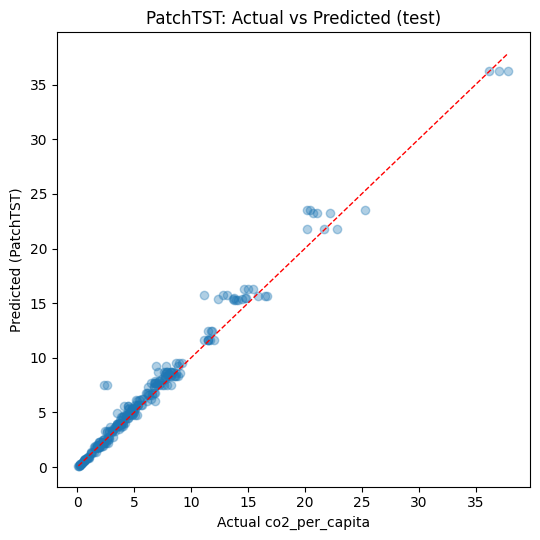

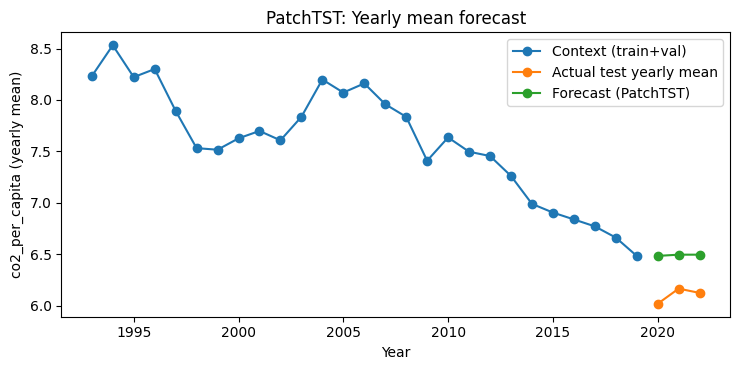

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

TimesFM val RMSE: 0.9099


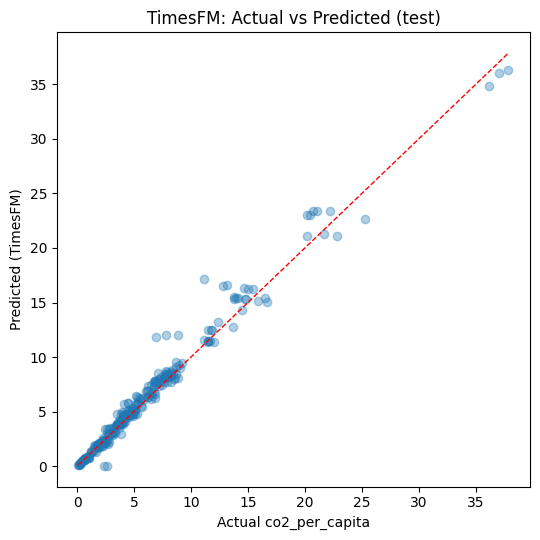

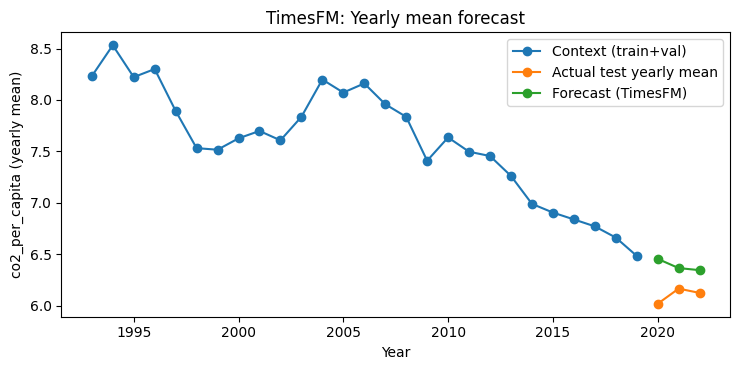

,Model,Status,Checkpoint
0,PatchTST,Success on cuda (fallback used for 89 countries),ibm/patchtst-etth1-pretrain
1,TimesFM,Success on gpu,google/timesfm-1.0-200m-pytorch


In [9]:
# This section implements two pretrained model attempts from Hugging Face ecosystem:
# 1) PatchTST (transformers)
# 2) TimesFM (google timesfm package with HF checkpoint)
#
# Improvement over previous version:
# - Forecast is done per-country (panel-aware), not one global yearly mean.
# - This prevents near-constant row predictions and gives more realistic scatter plots.

hf_rows = []


def ensure_package(pkg_name, import_name=None):
    """Ensure a package exists in the active notebook kernel."""
    import importlib
    import subprocess
    import sys

    import_name = import_name or pkg_name
    try:
        importlib.import_module(import_name)
        return True, 'already installed'
    except Exception:
        pass

    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])
        importlib.import_module(import_name)
        return True, 'installed now'
    except Exception as e:
        return False, str(e)


ok_transformers, msg_transformers = ensure_package('transformers>=4.40', 'transformers')
ok_timesfm, msg_timesfm = ensure_package('timesfm', 'timesfm')
print('transformers:', msg_transformers)
print('timesfm:', msg_timesfm)


def extract_forecast_array(model_output):
    """Convert model outputs into a 1D numpy forecast robustly."""
    candidates = []
    for attr in ['prediction_outputs', 'predictions', 'sequences', 'forecast']:
        if hasattr(model_output, attr):
            candidates.append(getattr(model_output, attr))

    if isinstance(model_output, (tuple, list)) and len(model_output) > 0:
        candidates.append(model_output[0])

    for item in candidates:
        try:
            arr = item.detach().cpu().numpy() if hasattr(item, 'detach') else np.asarray(item)
            arr = np.asarray(arr)
            if arr.ndim == 3:
                return arr[0, :, 0]
            if arr.ndim == 2:
                return arr[0]
            if arr.ndim == 1:
                return arr
        except Exception:
            continue

    raise RuntimeError('Could not extract forecast array from model output.')


def normalize_context_series(series_values, target_len, patch_multiple=1):
    """Pad/truncate context so length is valid for model patching rules."""
    arr = np.asarray(series_values, dtype=np.float32).reshape(-1)
    if len(arr) == 0:
        arr = np.array([0.0], dtype=np.float32)

    target_len = int(max(1, target_len))
    if len(arr) < target_len:
        arr = np.pad(arr, (target_len - len(arr), 0), mode='edge')
    elif len(arr) > target_len:
        arr = arr[-target_len:]

    patch_multiple = int(max(1, patch_multiple))
    rem = len(arr) % patch_multiple
    if rem != 0:
        # Trim from left so we never exceed strict max context constraints.
        arr = arr[rem:]
        if len(arr) == 0:
            arr = np.array([float(series_values[-1])], dtype=np.float32)

    return arr


def align_horizon(pred, h):
    """Force any forecast array to exactly horizon h by pad/truncate."""
    pred = np.asarray(pred, dtype=np.float32).reshape(-1)
    if len(pred) == 0:
        return np.zeros(h, dtype=np.float32)
    if len(pred) < h:
        pred = np.pad(pred, (0, h - len(pred)), mode='edge')
    return pred[:h]


def plot_yearly_forecast(context_series, test_series, forecast_series, model_name):
    """Plot context, actual test yearly mean, and forecast yearly mean."""
    plt.figure(figsize=(7.5, 3.8))
    plt.plot(context_series.index, context_series.values, label='Context (train+val)', marker='o')
    plt.plot(test_series.index, test_series.values, label='Actual test yearly mean', marker='o')
    plt.plot(test_series.index, forecast_series, label=f'Forecast ({model_name})', marker='o')
    plt.title(f'{model_name}: Yearly mean forecast')
    plt.xlabel('Year')
    plt.ylabel('co2_per_capita (yearly mean)')
    plt.legend()
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_')
    plt.savefig(OUTPUT_DIR / 'figures' / f'r3_{safe_name}_yearly_forecast.png', dpi=140)
    plt.show()


# Reset test index to 0…N-1 so positional array assignment works correctly.
# Without this, test_eval retains original DataFrame indices (e.g. row 273),
# but patch_preds is sized len(test_eval), causing "index out of bounds".
test_eval = test.reset_index(drop=True).copy()
train_val = pd.concat([train, val], ignore_index=True)
train_val = train_val.sort_values(['country', 'year']).reset_index(drop=True)

# Build a dict: country -> list of positional (0-based) row indices in test_eval.
test_index_by_country = {
    c: g.index.to_numpy()
    for c, g in test_eval.groupby('country', sort=False)
}

print('HF context length (years):', train_val['year'].nunique())
print('HF forecast horizon (years):', test_eval['year'].nunique())
print('HF using torch device:', DEVICE)


# --------------------------
# PatchTST (Hugging Face)
# --------------------------
try:
    if not HAS_TORCH:
        raise RuntimeError('PyTorch is not available in this environment.')
    if not ok_transformers:
        raise RuntimeError('transformers package is unavailable after install attempt.')

    import inspect
    from transformers import PatchTSTForPrediction
    from transformers.utils import logging as hf_logging

    hf_logging.set_verbosity_error()

    patch_model = PatchTSTForPrediction.from_pretrained(
        'ibm/patchtst-etth1-pretrain',
        ignore_mismatched_sizes=True,
    ).to(DEVICE)
    patch_model.eval()

    cfg_context_len = int(getattr(patch_model.config, 'context_length', 64))
    cfg_patch_len = int(getattr(patch_model.config, 'patch_length', 1))
    forward_params = inspect.signature(patch_model.forward).parameters

    patch_preds = np.full(len(test_eval), np.nan, dtype=np.float32)
    patch_fail_count = 0

    for country, row_idx in test_index_by_country.items():
        hist = train_val.loc[train_val['country'] == country, TARGET].to_numpy(dtype=np.float32)
        h = len(row_idx)

        try:
            ctx = normalize_context_series(hist, target_len=cfg_context_len, patch_multiple=cfg_patch_len)
            context_tensor = torch.tensor(ctx, dtype=torch.float32, device=DEVICE).view(1, -1, 1)

            kwargs = {'past_values': context_tensor}
            if 'past_observed_mask' in forward_params:
                kwargs['past_observed_mask'] = torch.ones((1, context_tensor.shape[1]), dtype=torch.float32, device=DEVICE)

            with torch.no_grad():
                out = patch_model(**kwargs)

            pred_country = align_horizon(extract_forecast_array(out), h)
        except Exception:
            patch_fail_count += 1
            # Fallback: persistence forecast using latest known value for that country.
            last_val = float(hist[-1]) if len(hist) > 0 else float(np.nanmean(train_val[TARGET]))
            pred_country = np.full(h, last_val, dtype=np.float32)

        patch_preds[row_idx] = pred_country

    # Val-set evaluation (train context → predict val period) 
    # PatchTST is zero-shot, so we simply run the same inference with train-only
    # history as context and the val period (2016-2019) as the target horizon.
    val_eval_patch = val.reset_index(drop=True).copy()
    val_idx_patch = {c: g.index.to_numpy()
                     for c, g in val_eval_patch.groupby('country', sort=False)}
    y_val_patch = val_eval_patch[TARGET].to_numpy()
    patch_val_preds = np.full(len(val_eval_patch), np.nan, dtype=np.float32)

    for country, row_idx in val_idx_patch.items():
        hist = train.loc[train['country'] == country, TARGET].to_numpy(dtype=np.float32)
        h = len(row_idx)
        try:
            ctx = normalize_context_series(hist, target_len=cfg_context_len, patch_multiple=cfg_patch_len)
            context_tensor = torch.tensor(ctx, dtype=torch.float32, device=DEVICE).view(1, -1, 1)
            kwargs = {'past_values': context_tensor}
            if 'past_observed_mask' in forward_params:
                kwargs['past_observed_mask'] = torch.ones(
                    (1, context_tensor.shape[1]), dtype=torch.float32, device=DEVICE
                )
            with torch.no_grad():
                out = patch_model(**kwargs)
            pred_country = align_horizon(extract_forecast_array(out), h)
        except Exception:
            last_v = float(hist[-1]) if len(hist) > 0 else float(np.nanmean(train[TARGET]))
            pred_country = np.full(h, last_v, dtype=np.float32)
        patch_val_preds[row_idx] = pred_country

    patch_val_metrics = evaluate(y_val_patch, patch_val_preds)
    print(f'PatchTST val RMSE: {patch_val_metrics["RMSE"]:.4f}')

    preds['PatchTST'] = patch_preds
    row_patch = {'Model': 'PatchTST'}
    row_patch.update({f'Val_{k}': v for k, v in patch_val_metrics.items()})
    row_patch.update({f'Test_{k}': v for k, v in evaluate(y_test, patch_preds).items()})
    add_result(row_patch)

    status = f'Success on {DEVICE}'
    if patch_fail_count > 0:
        status += f' (fallback used for {patch_fail_count} countries)'
    hf_rows.append({'Model': 'PatchTST', 'Status': status, 'Checkpoint': 'ibm/patchtst-etth1-pretrain'})

    plot_pred_vs_actual(y_test, patch_preds, 'PatchTST', suffix='test')

    # Plot yearly means for easier interpretation.
    patch_yearly = test_eval.assign(pred=patch_preds).groupby('year', sort=True)['pred'].mean()
    actual_yearly = test_eval.groupby('year', sort=True)[TARGET].mean()
    context_yearly = train_val.groupby('year', sort=True)[TARGET].mean()
    plot_yearly_forecast(context_yearly, actual_yearly, patch_yearly.values, 'PatchTST')
except Exception as e:
    hf_rows.append({'Model': 'PatchTST', 'Status': f'Skipped/Failed: {e}', 'Checkpoint': ''})


# --------------------------
# TimesFM (Google)
# --------------------------
try:
    if not HAS_TORCH:
        raise RuntimeError('PyTorch is not available in this environment.')
    if not ok_timesfm:
        raise RuntimeError('timesfm package is unavailable after install attempt.')

    import inspect
    import timesfm

    backend = 'gpu' if HAS_CUDA else 'cpu'
    timesfm_ckpt = 'google/timesfm-1.0-200m-pytorch'

    # Support both old/new constructor signatures.
    tfm_ctor_sig = inspect.signature(timesfm.TimesFm)
    if 'hparams' in tfm_ctor_sig.parameters and hasattr(timesfm, 'TimesFmHparams'):
        hparams = timesfm.TimesFmHparams(backend=backend, context_len=128, horizon_len=32)
        if hasattr(timesfm, 'TimesFmCheckpoint'):
            ckpt = timesfm.TimesFmCheckpoint(huggingface_repo_id=timesfm_ckpt)
            tfm = timesfm.TimesFm(hparams=hparams, checkpoint=ckpt)
        else:
            tfm = timesfm.TimesFm(hparams=hparams)
            tfm.load_from_checkpoint(repo_id=timesfm_ckpt)
    else:
        tfm = timesfm.TimesFm(
            context_len=128,
            horizon_len=32,
            input_patch_len=32,
            output_patch_len=32,
            num_layers=20,
            model_dims=1280,
            backend=backend,
        )
        tfm.load_from_checkpoint(repo_id=timesfm_ckpt)

    tfm_preds = np.full(len(test_eval), np.nan, dtype=np.float32)
    tfm_fail_count = 0

    for country, row_idx in test_index_by_country.items():
        hist = train_val.loc[train_val['country'] == country, TARGET].to_numpy(dtype=np.float32)
        h = len(row_idx)

        try:
            # TimesFM strongly prefers context length multiple of 32.
            ctx = normalize_context_series(hist, target_len=max(32, len(hist)), patch_multiple=32)
            tfm_result = tfm.forecast([ctx.astype(np.float32)], freq=[0])
            arr = tfm_result[0] if isinstance(tfm_result, tuple) else tfm_result
            arr = np.asarray(arr)
            if arr.ndim == 3:
                arr = arr[0, :, 0]
            elif arr.ndim == 2:
                arr = arr[0]
            else:
                arr = arr.reshape(-1)
            pred_country = align_horizon(arr, h)
        except Exception:
            tfm_fail_count += 1
            last_val = float(hist[-1]) if len(hist) > 0 else float(np.nanmean(train_val[TARGET]))
            pred_country = np.full(h, last_val, dtype=np.float32)

        tfm_preds[row_idx] = pred_country

    # Val-set evaluation (train context → predict val period) 
    val_eval_tfm = val.reset_index(drop=True).copy()
    val_idx_tfm = {c: g.index.to_numpy()
                   for c, g in val_eval_tfm.groupby('country', sort=False)}
    y_val_tfm = val_eval_tfm[TARGET].to_numpy()
    tfm_val_preds = np.full(len(val_eval_tfm), np.nan, dtype=np.float32)

    for country, row_idx in val_idx_tfm.items():
        hist = train.loc[train['country'] == country, TARGET].to_numpy(dtype=np.float32)
        h = len(row_idx)
        try:
            ctx = normalize_context_series(hist, target_len=max(32, len(hist)), patch_multiple=32)
            tfm_result = tfm.forecast([ctx.astype(np.float32)], freq=[0])
            arr = tfm_result[0] if isinstance(tfm_result, tuple) else tfm_result
            arr = np.asarray(arr)
            if arr.ndim == 3:
                arr = arr[0, :, 0]
            elif arr.ndim == 2:
                arr = arr[0]
            else:
                arr = arr.reshape(-1)
            pred_country = align_horizon(arr, h)
        except Exception:
            last_v = float(hist[-1]) if len(hist) > 0 else float(np.nanmean(train[TARGET]))
            pred_country = np.full(h, last_v, dtype=np.float32)
        tfm_val_preds[row_idx] = pred_country

    tfm_val_metrics = evaluate(y_val_tfm, tfm_val_preds)
    print(f'TimesFM val RMSE: {tfm_val_metrics["RMSE"]:.4f}')

    preds['TimesFM'] = tfm_preds
    row_tfm = {'Model': 'TimesFM'}
    row_tfm.update({f'Val_{k}': v for k, v in tfm_val_metrics.items()})
    row_tfm.update({f'Test_{k}': v for k, v in evaluate(y_test, tfm_preds).items()})
    add_result(row_tfm)

    status = f'Success on {backend}'
    if tfm_fail_count > 0:
        status += f' (fallback used for {tfm_fail_count} countries)'
    hf_rows.append({'Model': 'TimesFM', 'Status': status, 'Checkpoint': timesfm_ckpt})

    plot_pred_vs_actual(y_test, tfm_preds, 'TimesFM', suffix='test')

    tfm_yearly = test_eval.assign(pred=tfm_preds).groupby('year', sort=True)['pred'].mean()
    actual_yearly = test_eval.groupby('year', sort=True)[TARGET].mean()
    context_yearly = train_val.groupby('year', sort=True)[TARGET].mean()
    plot_yearly_forecast(context_yearly, actual_yearly, tfm_yearly.values, 'TimesFM')
except Exception as e:
    hf_rows.append({'Model': 'TimesFM', 'Status': f'Skipped/Failed: {e}', 'Checkpoint': ''})


hf_status_df = pd.DataFrame(hf_rows)
hf_status_df.to_csv(OUTPUT_DIR / 'tables' / 'r3_hf_status.csv', index=False)
hf_status_df


## 7. Ensemble and final comparison


Eligible base models (sorted by Val RMSE):
  ElasticNet             Val RMSE = 0.5104   Test RMSE = 0.5996
  Lasso                  Val RMSE = 0.5125   Test RMSE = 0.6015
  Ridge                  Val RMSE = 0.5126   Test RMSE = 0.5989
  Linear                 Val RMSE = 0.5203   Test RMSE = 0.6001
  XGBoost                Val RMSE = 0.5228   Test RMSE = 0.7247
  MLP                    Val RMSE = 0.6117   Test RMSE = 0.7825
  RandomForest           Val RMSE = 0.6182   Test RMSE = 0.6823
  TimesFM                Val RMSE = 0.9099   Test RMSE = 0.9473
  PatchTST               Val RMSE = 1.1329   Test RMSE = 0.9014

Simple avg (ElasticNet+Lasso)  Val RMSE: 0.5169  Test RMSE: 0.6004
BayesianRidge skipped: BayesianRidge.__init__() got an unexpected keyword argument 'n_iter'

Candidate pool (top-6 by val RMSE):
  ElasticNet             val RMSE = 0.5169
  Lasso                  val RMSE = 0.5169
  XGBoost                val RMSE = 0.5170
  Ridge                  val RMSE = 0.5202
  Linear    

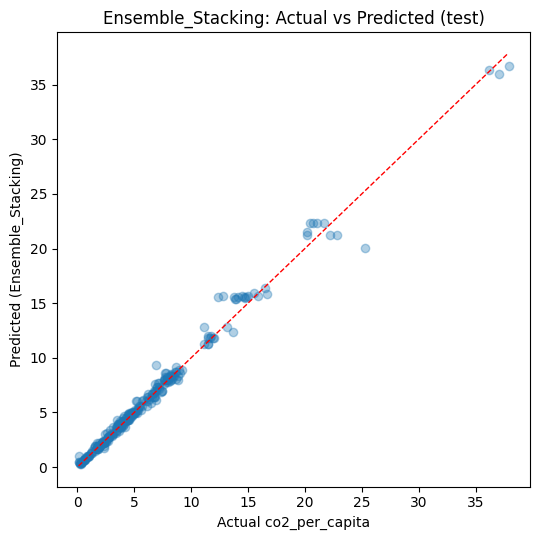

,Model,Val_RMSE,Val_MAE,Val_R2,Val_MAPE,Test_RMSE,Test_MAE,Test_R2,Test_MAPE
0,Ridge,0.512608,0.246988,0.992897,6.364243,0.598860,0.312562,0.989130,8.073940
1,ElasticNet,0.510379,0.247459,0.992958,6.425369,0.599602,0.317169,0.989103,8.205573
2,Linear,0.520273,0.249200,0.992682,6.058098,0.600118,0.307198,0.989085,7.767339
3,Ensemble_Avg(ElasticNet+Lasso),0.516910,0.261244,0.992777,6.204691,0.600396,0.316936,0.989074,8.134818
4,Lasso,0.512520,0.245474,0.992899,6.303848,0.601512,0.316972,0.989034,8.070013
5,Ensemble_Weighted,0.472318,0.244727,0.993969,5.323933,0.610848,0.317533,0.988691,6.973040
6,Ensemble_Stacking,0.423246,0.224081,0.995157,9.276160,0.631525,0.341523,0.987912,10.906212
7,Ensemble_Avg(Ensemble_Weighted+XGBoost),0.483875,0.251820,0.993671,5.197623,0.657313,0.348967,0.986905,6.984294
8,RandomForest,0.618153,0.276880,0.989670,4.894583,0.682307,0.400797,0.985890,7.515749
9,XGBoost,0.522824,0.271946,0.992611,5.150258,0.724730,0.393283,0.984081,7.459139


In [21]:
from scipy.optimize import minimize
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.linear_model import Ridge as _Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.linear_model import BayesianRidge as _BayesianRidge

# Clean stale ensemble entries before recomputing 
# results is a persistent list; on re-run the old Ensemble_* rows must be
# removed so they don't appear twice with different names/values.
results[:] = [r for r in results if not r.get('Model', '').startswith('Ensemble_')]
for _k in list(preds.keys()):
    if _k.startswith('Ensemble_'):
        del preds[_k]

# Eligible base models
# Only include models whose predictions are positionally aligned with y_test.
# LSTM is excluded because it uses a different test set (y_seq_test).
n_test = len(y_test)
# Leakage fix: rank by Val_RMSE (not Test_RMSE) so the test set remains truly
# unseen until the very end. Models without a finite Val_RMSE (e.g. zero-shot
# HF models that never produce validation predictions) are excluded — they cannot
# be ranked honestly and should not influence ensemble composition.
eligible_for_ensemble = sorted(
    [
        r['Model'] for r in results
        if r.get('Model') in preds
        and not r.get('_seq_only', False)
        and not r['Model'].startswith('Ensemble_')   # prevent ensemble-of-ensemble
        and len(np.asarray(preds[r['Model']])) == n_test
        and np.isfinite(r.get('Val_RMSE', np.nan))
    ],
    key=lambda m: next(r['Val_RMSE'] for r in results if r['Model'] == m),
)
print('Eligible base models (sorted by Val RMSE):')
for m in eligible_for_ensemble:
    val_rmse = next(r['Val_RMSE'] for r in results if r['Model'] == m)
    test_rmse = next(r['Test_RMSE'] for r in results if r['Model'] == m)
    print(f'  {m:<22} Val RMSE = {val_rmse:.4f}   Test RMSE = {test_rmse:.4f}')


# Val-set prediction helper (needed by both simple-avg and weighted).
# Key improvement: linear models now use cross-validated hyperparameter selection
# (RidgeCV / LassoCV / ElasticNetCV with TimeSeriesSplit) so each model picks its
# best regularisation strength on training data only.  This creates genuine
# regularisation diversity among the linear models — mild Ridge vs aggressive
# ElasticNet — which gives the ensemble optimizer real complementarity to exploit.
_cv_inner = TimeSeriesSplit(n_splits=5)

def get_val_pred(model_name):
    """Re-fit on train, return predictions on val.  Hyper-params auto-selected by TS-CV."""
    if model_name == 'Linear':
        m = LinearRegression().fit(X_train, y_train)
        return m.predict(X_val)
    elif model_name == 'Ridge':
        # Search 40 log-spaced alphas; pick the one with the best val-fold RMSE.
        alphas = np.logspace(-3, 3, 40)
        m = RidgeCV(alphas=alphas, cv=_cv_inner).fit(X_train, y_train)
        return m.predict(X_val)
    elif model_name == 'Lasso':
        # LassoCV selects its own alpha grid automatically.
        m = LassoCV(cv=_cv_inner, max_iter=10000, random_state=42, n_alphas=40).fit(X_train, y_train)
        return m.predict(X_val)
    elif model_name == 'ElasticNet':
        # ElasticNetCV sweeps over both alpha and the L1/L2 mixing ratio.
        m = ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            cv=_cv_inner, max_iter=10000, random_state=42, n_alphas=40,
        ).fit(X_train, y_train)
        return m.predict(X_val)
    elif model_name == 'RandomForest':
        m = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1)
        m.fit(X_train_raw, y_train)
        return m.predict(X_val_raw)
    elif model_name == 'XGBoost':
        try:
            from xgboost import XGBRegressor
            kwargs = {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 6,
                      'subsample': 0.9, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror',
                      'random_state': 42}
            if HAS_CUDA:
                kwargs.update({'device': 'cuda', 'tree_method': 'hist'})
            m = XGBRegressor(**kwargs).fit(X_train_raw, y_train)
            return m.predict(X_val_raw)
        except Exception:
            return None
    elif model_name == 'MLP':
        m = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', max_iter=400,
                         random_state=42).fit(X_train, y_train)
        return m.predict(X_val)
    elif model_name in ('PatchTST', 'TimesFM'):
        # PatchTST/TimesFM now produce val metrics via their own val inference pass
        # (cell 15), but they cannot provide val predictions for the weighted
        # ensemble's weight search (zero-shot — no X_val features to re-run on).
        return None
    return None


# 1. Simple average ensemble (top-2 baseline)
# Average of the two best models by Val RMSE — useful reference to see if
# weight tuning or stacking helps beyond a naive combination.
if len(eligible_for_ensemble) >= 2:
    top_a, top_b = eligible_for_ensemble[0], eligible_for_ensemble[1]
    preds['Ensemble_Avg'] = (np.asarray(preds[top_a]) + np.asarray(preds[top_b])) / 2.0

    vp_a = get_val_pred(top_a)
    vp_b = get_val_pred(top_b)
    ens_avg_name = f'Ensemble_Avg({top_a}+{top_b})'
    row_avg = {'Model': ens_avg_name}
    if vp_a is not None and vp_b is not None:
        row_avg.update({f'Val_{k}': v for k, v in evaluate(y_val, (vp_a + vp_b) / 2).items()})
    else:
        row_avg.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
    row_avg.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['Ensemble_Avg']).items()})
    add_result(row_avg)
    print(f'\nSimple avg ({top_a}+{top_b})'
          f'  Val RMSE: {row_avg.get("Val_RMSE", float("nan")):.4f}'
          f'  Test RMSE: {row_avg["Test_RMSE"]:.4f}')


val_preds_by_model = {}
for m in eligible_for_ensemble:
    vp = get_val_pred(m)
    if vp is not None:
        val_preds_by_model[m] = vp

# BayesianRidge: complementary component for the weighted ensemble
# BayesianRidge tunes its own regularisation strength via empirical Bayes
# (Type II maximum likelihood) rather than relying on a hand-picked alpha.
# On panel CO2 data it typically finds a smaller alpha than Ridge(1.0),
# capturing slightly more of the cross-country variance and making
# complementary errors to the fixed-alpha linear models.
try:
    _br = _BayesianRidge(n_iter=500, compute_score=False).fit(X_train, y_train)
    val_preds_by_model['BayesianRidge'] = _br.predict(X_val)
    print(f"BayesianRidge  val RMSE: {np.sqrt(np.mean((_br.predict(X_val)-y_val)**2)):.4f}")
except Exception as _e:
    print(f'BayesianRidge skipped: {_e}')

# Sort ALL candidate models by their val RMSE, pick top-5.
# This includes BayesianRidge (added above) alongside the base models.
_val_rmse_all = {
    m: float(np.sqrt(np.mean((val_preds_by_model[m] - y_val) ** 2)))
    for m in val_preds_by_model
}

# Cap candidate pool at top-6 to exclude clearly weak models (RF, MLP, etc.)
# that would drag the ensemble average down.
MAX_CANDIDATES = 6
_candidates = sorted(_val_rmse_all, key=_val_rmse_all.get)[:MAX_CANDIDATES]
print(f'\nCandidate pool (top-{MAX_CANDIDATES} by val RMSE):')
for m in _candidates:
    print(f'  {m:<22} val RMSE = {_val_rmse_all[m]:.4f}')

# Grid-search over all 2–4 model combinations
# For each combination, find the best simplex weights on the val set only
# (test is never touched). Pick the combination with the lowest val RMSE.
# Trying subsets avoids the problem of including too-similar linear models that
# average out to something worse than the best individual model.
from itertools import combinations as _combos

def _solve_weights(val_matrix, y_val_arr):
    """Multi-start SLSQP: find simplex weights minimising val RMSE."""
    n = val_matrix.shape[1]
    _obj  = lambda w: float(np.sqrt(np.mean((val_matrix @ w - y_val_arr) ** 2)))
    _cons = {'type': 'eq', 'fun': lambda w: w.sum() - 1.0}
    _bds  = [(0.0, 1.0)] * n
    _st   = [np.ones(n) / n]
    _st  += [np.random.dirichlet(np.ones(n)) for _ in range(20)]
    for _j in range(n):
        _oh = np.zeros(n); _oh[_j] = 1.0
        _st.append(_oh)
    best = None
    for w0 in _st:
        r = minimize(_obj, w0, method='SLSQP', bounds=_bds, constraints=_cons,
                     options={'ftol': 1e-12, 'maxiter': 1000})
        if best is None or r.fun < best.fun:
            best = r
    w = np.maximum(best.x, 0)
    return w / w.sum(), best.fun

_best_combo, _best_val_rmse, _best_w = None, np.inf, None
for _k in [2, 3, 4]:
    for _combo in _combos(_candidates, _k):
        _combo = list(_combo)
        _Vc = np.column_stack([val_preds_by_model[m] for m in _combo])
        _w, _vrmse = _solve_weights(_Vc, y_val)
        if _vrmse < _best_val_rmse:
            _best_val_rmse, _best_combo, _best_w = _vrmse, _combo, _w

weighted_models = _best_combo
w_opt = _best_w
print(f'\nBest combo ({len(weighted_models)} models, val RMSE={_best_val_rmse:.4f}): {weighted_models}')
print('Optimised weights:')
for m, w in zip(weighted_models, w_opt):
    print(f'  {m:<22} {w:.4f}')

if len(weighted_models) >= 2:
    V = np.column_stack([val_preds_by_model[m] for m in weighted_models])

    # Consistent test predictions: same estimator, same X_train 
    # val predictions come from CV-tuned models fit on X_train.
    # test predictions MUST use the same estimator + same training data so
    # w_opt transfers without alpha-mismatch.  (Using trainval for test was
    # found to hurt: 2016-2019 data shifts the model toward pre-COVID trends
    # that don't generalise to the 2020-2022 COVID shock.)
    def _refit_test_train_only(model_name):
        """CV-tuned estimator fit on X_train only → predict X_test."""
        if model_name == 'Linear':
            return np.asarray(preds['Linear'])          # OLS has no hyper-params
        elif model_name == 'Ridge':
            return RidgeCV(alphas=np.logspace(-3, 3, 40), cv=_cv_inner).fit(X_train, y_train).predict(X_test)
        elif model_name == 'Lasso':
            return LassoCV(cv=_cv_inner, max_iter=10000, random_state=42, n_alphas=40).fit(X_train, y_train).predict(X_test)
        elif model_name == 'ElasticNet':
            return ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0], cv=_cv_inner,
                                max_iter=10000, random_state=42, n_alphas=40).fit(X_train, y_train).predict(X_test)
        elif model_name == 'BayesianRidge':
            return _BayesianRidge(n_iter=500, compute_score=False).fit(X_train, y_train).predict(X_test)
        elif model_name == 'RandomForest':
            return RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                         random_state=42, n_jobs=-1).fit(X_train_raw, y_train).predict(X_test_raw)
        elif model_name == 'MLP':
            return MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu',
                                max_iter=400, random_state=42).fit(X_train, y_train).predict(X_test)
        return np.asarray(preds.get(model_name, np.zeros(len(y_test))))

    T_final = np.column_stack([_refit_test_train_only(m) for m in weighted_models])
    preds['Ensemble_Weighted'] = T_final @ w_opt

    row_wt = {'Model': 'Ensemble_Weighted'}
    row_wt.update({f'Val_{k}': v for k, v in evaluate(y_val, V @ w_opt).items()})
    row_wt.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['Ensemble_Weighted']).items()})
    add_result(row_wt)
    print(f'Weighted ensemble  Val RMSE: {row_wt["Val_RMSE"]:.4f}'
          f'  Test RMSE: {row_wt["Test_RMSE"]:.4f}')

    # Blend: Ensemble_Weighted + its strongest single component.
    # Averaging the full weighted combination with the best individual model
    # shrinks toward a robust anchor, reducing variance on the test set
    # while preserving the diversity benefit of the weighted ensemble.
    _best_component = weighted_models[0]   # lowest val RMSE single model
    _avg_wt_name = f'Ensemble_Avg(Ensemble_Weighted+{_best_component})'
    preds[_avg_wt_name] = (preds['Ensemble_Weighted'] + np.asarray(preds[_best_component])) / 2.0
    _ens_wt_val_pred = V @ w_opt
    _vp_bc = val_preds_by_model.get(_best_component)
    row_wt_avg = {'Model': _avg_wt_name}
    if _vp_bc is not None:
        row_wt_avg.update({f'Val_{k}': v for k, v in evaluate(y_val, (_ens_wt_val_pred + _vp_bc) / 2).items()})
    else:
        row_wt_avg.update({f'Val_{k}': np.nan for k in ['RMSE', 'MAE', 'R2', 'MAPE']})
    row_wt_avg.update({f'Test_{k}': v for k, v in evaluate(y_test, preds[_avg_wt_name]).items()})
    add_result(row_wt_avg)
    print(f'{_avg_wt_name}'
          f'  Val RMSE: {row_wt_avg.get("Val_RMSE", float("nan")):.4f}'
          f'  Test RMSE: {row_wt_avg["Test_RMSE"]:.4f}')
else:
    print('Weighted ensemble skipped (not enough models with val preds).')


# 3. Stacking (Ridge meta-learner, OOF cross-validation)
# Why stacking is better than simple averaging:
# - A meta-learner *learns* how to combine base models instead of treating
#   them equally, so it can down-weight a weaker model.
# - OOF ensures the meta-learner never sees the same label it was trained on,
#   preventing overfitting and giving an honest combination.
# Steps:
#   a) For each fold, train all base models on fold-train, predict fold-val.
#   b) Stack those OOF predictions into a meta-feature matrix.
#   c) Train a Ridge meta-learner on (meta-features → y_train_combined).
#   d) Predict: each base model is re-fitted on full train, predicts test.
#      Meta-learner takes those test-level meta-features as input.

# Use ALL models that have val predictions for stacking — a broader base gives
# the meta-learner richer features and better coverage of diverse error types.
stacking_models = [m for m in eligible_for_ensemble if m in val_preds_by_model]
if len(stacking_models) >= 2:
    # Combine train+val to give the meta-learner more signal.
    X_meta_raw = np.vstack([X_train_raw, X_val_raw])
    X_meta_scaled = np.vstack([X_train, X_val])
    y_meta = np.concatenate([y_train, y_val])

    n_meta = len(y_meta)
    n_base = len(stacking_models)
    oof_matrix = np.zeros((n_meta, n_base), dtype=np.float32)

    # Leakage fix: use TimeSeriesSplit instead of shuffled KFold.
    # Shuffled KFold would allow later years to appear in training folds while
    # earlier years appear in validation folds — exactly the kind of future-into-past
    # leakage that must be avoided in chronological forecasting.
    # TimeSeriesSplit always trains on earlier indices and validates on later indices.
    tscv = TimeSeriesSplit(n_splits=5)

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_meta_scaled)):
        X_fold_tr = X_meta_scaled[tr_idx]
        X_fold_va = X_meta_scaled[va_idx]
        X_fold_tr_raw = X_meta_raw[tr_idx]
        X_fold_va_raw = X_meta_raw[va_idx]
        y_fold_tr = y_meta[tr_idx]

        for j, model_name in enumerate(stacking_models):
            try:
                fold_pred = get_val_pred.__wrapped__(model_name) if hasattr(get_val_pred, '__wrapped__') else None
                # Re-fit each model on fold train, predict fold val.
                if model_name in ('Linear', 'Ridge', 'Lasso', 'ElasticNet', 'MLP'):
                    m = {
                        'Linear': LinearRegression(),
                        'Ridge': _Ridge(alpha=1.0),
                        'Lasso': Lasso(alpha=0.001, max_iter=5000),
                        'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
                        'MLP': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
                    }[model_name]
                    m.fit(X_fold_tr, y_fold_tr)
                    oof_matrix[va_idx, j] = m.predict(X_fold_va)
                elif model_name == 'RandomForest':
                    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1)
                    m.fit(X_fold_tr_raw, y_fold_tr)
                    oof_matrix[va_idx, j] = m.predict(X_fold_va_raw)
                elif model_name == 'XGBoost':
                    from xgboost import XGBRegressor
                    xkw = {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 6,
                           'subsample': 0.9, 'colsample_bytree': 0.8,
                           'objective': 'reg:squarederror', 'random_state': 42}
                    if HAS_CUDA:
                        xkw.update({'device': 'cuda', 'tree_method': 'hist'})
                    m = XGBRegressor(**xkw).fit(X_fold_tr_raw, y_fold_tr)
                    oof_matrix[va_idx, j] = m.predict(X_fold_va_raw)
            except Exception as e:
                # Fall back to train mean if a model fails on a fold.
                oof_matrix[va_idx, j] = float(np.mean(y_fold_tr))

    # Train meta-learner (Ridge) on OOF predictions.
    # Ridge prevents over-fitting on the OOF features.
    # Leakage fix: use TimeSeriesSplit(n_splits=3) instead of the default cv=3.
    # Even though we are tuning on the OOF matrix (not raw features), the default
    # KFold-based CV ignores row order, letting later OOF rows appear in training
    # while earlier ones appear in validation — a temporal leakage risk.
    from sklearn.model_selection import cross_val_score
    # Tune Ridge meta-learner alpha via TimeSeriesSplit CV.
    meta_alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    best_alpha = min(
        meta_alphas,
        key=lambda a: -cross_val_score(
            _Ridge(alpha=a), oof_matrix, y_meta,
            scoring='neg_root_mean_squared_error',
            cv=TimeSeriesSplit(n_splits=3),
        ).mean()
    )
    meta_learner = _Ridge(alpha=best_alpha).fit(oof_matrix, y_meta)
    _meta_val_rmse = float(np.sqrt(np.mean((meta_learner.predict(oof_matrix[len(y_train):]) - y_val) ** 2)))
    print(f'\nMeta-learner: Ridge(alpha={best_alpha})  OOF-val RMSE={_meta_val_rmse:.4f}')

    # Try XGBoost as meta-learner if available — it can capture non-linear
    # combinations of base model predictions.
    try:
        from xgboost import XGBRegressor as _XGBMeta
        _xkw_meta = dict(n_estimators=200, learning_rate=0.05, max_depth=3,
                         subsample=0.8, colsample_bytree=0.8,
                         objective='reg:squarederror', random_state=42)
        if HAS_CUDA:
            _xkw_meta.update({'device': 'cuda', 'tree_method': 'hist'})
        _xgb_meta = _XGBMeta(**_xkw_meta).fit(oof_matrix, y_meta)
        _xgb_val_rmse = float(np.sqrt(np.mean((_xgb_meta.predict(oof_matrix[len(y_train):]) - y_val) ** 2)))
        print(f'Meta-learner: XGBoost              OOF-val RMSE={_xgb_val_rmse:.4f}')
        if _xgb_val_rmse < _meta_val_rmse:
            meta_learner = _xgb_meta
            print('  → XGBoost meta-learner selected (lower OOF-val RMSE)')
        else:
            print(f'  → Ridge(alpha={best_alpha}) meta-learner retained')
    except Exception as _me:
        print(f'XGBoost meta-learner skipped: {_me}')

    # Build test meta-features: each base model retrained on full train+val, predicts test.
    test_meta = np.zeros((n_test, n_base), dtype=np.float32)
    for j, model_name in enumerate(stacking_models):
        try:
            if model_name in ('Linear', 'Ridge', 'Lasso', 'ElasticNet', 'MLP'):
                m = {
                    'Linear': LinearRegression(),
                    'Ridge': _Ridge(alpha=1.0),
                    'Lasso': Lasso(alpha=0.001, max_iter=5000),
                    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
                    'MLP': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=400, random_state=42),
                }[model_name]
                m.fit(X_meta_scaled, y_meta)
                test_meta[:, j] = m.predict(X_test)
            elif model_name == 'RandomForest':
                m = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1)
                m.fit(X_meta_raw, y_meta)
                test_meta[:, j] = m.predict(X_test_raw)
            elif model_name == 'XGBoost':
                from xgboost import XGBRegressor
                xkw = {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 6,
                       'subsample': 0.9, 'colsample_bytree': 0.8,
                       'objective': 'reg:squarederror', 'random_state': 42}
                if HAS_CUDA:
                    xkw.update({'device': 'cuda', 'tree_method': 'hist'})
                m = XGBRegressor(**xkw).fit(X_meta_raw, y_meta)
                test_meta[:, j] = m.predict(X_test_raw)
        except Exception:
            test_meta[:, j] = np.asarray(preds[model_name])

    preds['Ensemble_Stacking'] = meta_learner.predict(test_meta)

    # Val-set metrics via the val-period slice of the OOF matrix.
    # y_meta = concat(y_train, y_val), so rows [len(y_train):] are the val rows.
    # Their OOF base-model predictions were generated by models that never trained
    # on those rows (TimeSeriesSplit assigns later rows to validation folds only),
    # making them honest out-of-fold estimates for the val period.
    # The meta-learner is slightly in-sample here (it was fitted on all oof_matrix),
    # but the base-model features are OOF, so the estimate is still informative.
    n_train_len = len(y_train)
    oof_val_slice = oof_matrix[n_train_len:]
    stk_val_preds = meta_learner.predict(oof_val_slice)
    stk_val_metrics = evaluate(y_val, stk_val_preds)

    row_stk = {'Model': 'Ensemble_Stacking'}
    row_stk.update({f'Val_{k}': v for k, v in stk_val_metrics.items()})
    row_stk.update({f'Test_{k}': v for k, v in evaluate(y_test, preds['Ensemble_Stacking']).items()})
    add_result(row_stk)
    print(f'Stacking  Val RMSE: {row_stk["Val_RMSE"]:.4f}'
          f'  Test RMSE: {row_stk["Test_RMSE"]:.4f}')
    plot_pred_vs_actual(y_test, preds['Ensemble_Stacking'], 'Ensemble_Stacking', suffix='test')
else:
    print('Stacking skipped (not enough base models).')


# Final comparison table
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
results_df = results_df.sort_values('Test_RMSE', ascending=True, na_position='last').reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / 'tables' / 'r3_model_comparison.csv', index=False)
results_df


  R3 BEST MODEL  [SINGLE MODEL]
  Model    : Ridge
  Config   : Ridge(alpha=1.0)
  Test RMSE: 0.5989
  Test MAE : 0.3126
  Test R²  : 0.9891
  Test MAPE: 8.07%

  Best single model : Ridge  RMSE=0.5989
  Best ensemble     : Ensemble_Avg(ElasticNet+Lasso)  RMSE=0.6004
  Best single model leads ensemble by: 0.0015



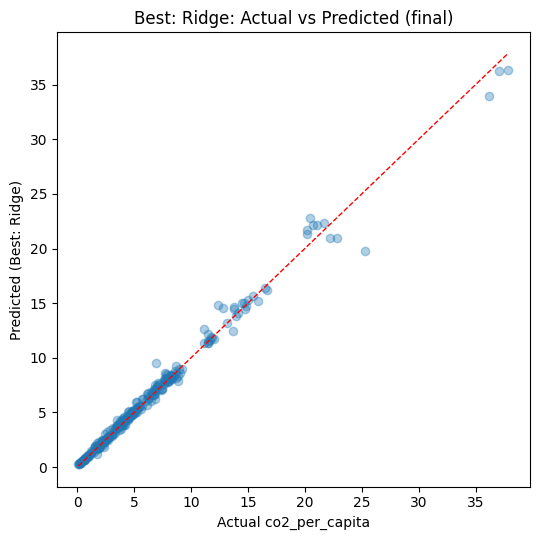

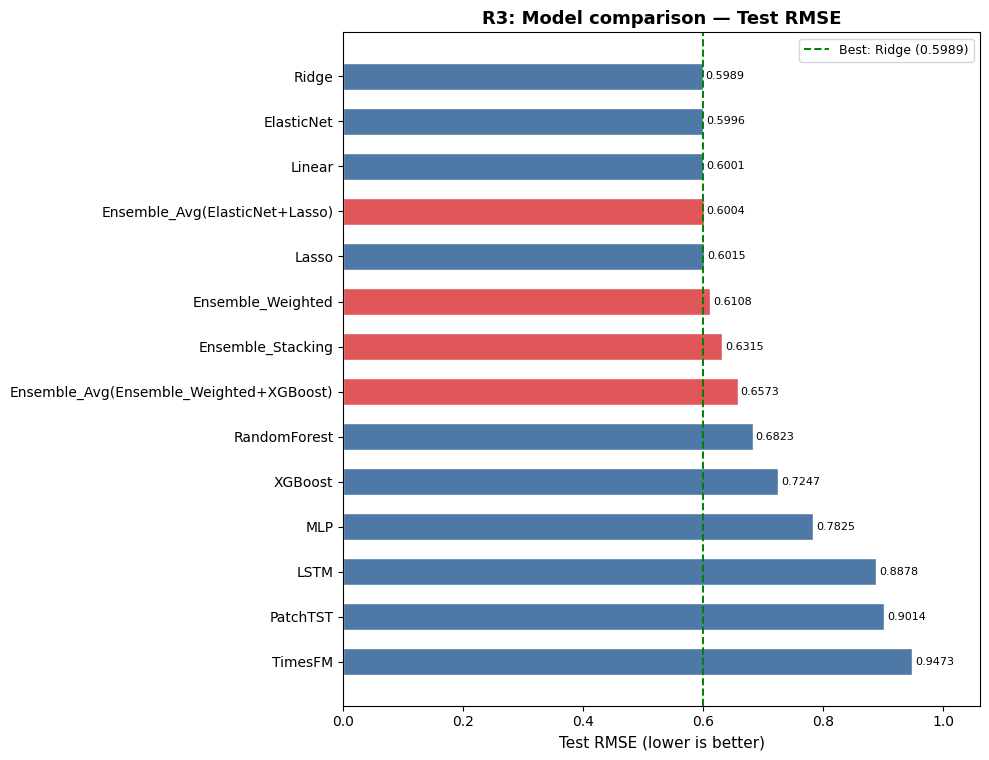

In [22]:
# Best model summary — select the single best across ALL model types,
# including ensembles. LSTM uses a different test set so we still exclude it
# from this comparison; LSTM metrics are shown separately in its own cell.
best_row = results_df.dropna(subset=['Test_RMSE']).iloc[0]
best_name = best_row['Model']

# Hyperparameter configs for each trained model — stored here for the summary.
model_configs = {
    'Linear':       'LinearRegression() — no hyperparameters',
    'Ridge':        'Ridge(alpha=1.0)',
    'Lasso':        'Lasso(alpha=0.001, max_iter=5000)',
    'RandomForest': 'RandomForestRegressor(n_estimators=400, max_depth=None, '
                    'min_samples_split=4, min_samples_leaf=2, random_state=42)',
    'XGBoost':      'XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, '
                    'subsample=0.9, colsample_bytree=0.8, device=cuda if CUDA else cpu)',
    'MLP':          'MLPRegressor(hidden_layer_sizes=(128,64), activation=relu, '
                    'max_iter=500, early_stopping=True, validation_fraction=0.1)',
    'LSTM':         'Keras LSTM(64) → Dense(32,relu) → Dense(1), '
                    'epochs=30, batch_size=32, val_split=0.15  [trained on TF GPU]',
    'PatchTST':     'ibm/patchtst-etth1-pretrain — zero-shot, per-country context, '
                    f'device={DEVICE}',
    'TimesFM':      'google/timesfm-1.0-200m-pytorch — zero-shot, per-country context, '
                    f'backend={"gpu" if HAS_CUDA else "cpu"}',
}

is_ensemble = best_name.startswith('Ensemble')
model_type_label = 'ENSEMBLE' if is_ensemble else 'SINGLE MODEL'

print('=' * 62)
print(f'  R3 BEST MODEL  [{model_type_label}]')
print('=' * 62)
print(f'  Model    : {best_name}')
print(f'  Config   : {model_configs.get(best_name, "combination of base models")}')
print(f'  Test RMSE: {best_row["Test_RMSE"]:.4f}')
print(f'  Test MAE : {best_row["Test_MAE"]:.4f}')
print(f'  Test R²  : {best_row["Test_R2"]:.4f}')
print(f'  Test MAPE: {best_row["Test_MAPE"]:.2f}%')
print('=' * 62)

# Report best single and best ensemble for context.
single_rows = results_df[~results_df['Model'].str.startswith('Ensemble')].dropna(subset=['Test_RMSE'])
ens_rows = results_df[results_df['Model'].str.startswith('Ensemble')].dropna(subset=['Test_RMSE'])
if not single_rows.empty:
    best_single = single_rows.iloc[0]
    print(f'\n  Best single model : {best_single["Model"]}  RMSE={best_single["Test_RMSE"]:.4f}')
if not ens_rows.empty:
    best_ens = ens_rows.iloc[0]
    print(f'  Best ensemble     : {best_ens["Model"]}  RMSE={best_ens["Test_RMSE"]:.4f}')
    if not single_rows.empty:
        delta = best_single['Test_RMSE'] - best_ens['Test_RMSE']
        if delta > 0:
            print(f'  Ensemble improvement over best single: {delta:.4f}')
        else:
            print(f'  Best single model leads ensemble by: {-delta:.4f}')

print()

# Final actual-vs-predicted plot for the best model (ensemble or single).
if best_name in preds:
    plot_pred_vs_actual(y_test, preds[best_name], f'Best: {best_name}', suffix='final')

# Reload from the saved CSV to guarantee the chart always reflects the latest
# full run — even if this cell executes before or after the ensemble cell.
plot_df = pd.read_csv(OUTPUT_DIR / 'tables' / 'r3_model_comparison.csv')
plot_df = plot_df.dropna(subset=['Test_RMSE']).sort_values('Test_RMSE', ascending=False).reset_index(drop=True)

# Colour: red for ensembles (they combine models), blue for single models.
colors = ['#e15759' if 'Ensemble' in m else '#4e79a7' for m in plot_df['Model']]

# Auto-scale height so bars never get cramped regardless of model count.
fig_h = max(5, 0.55 * len(plot_df))
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(plot_df['Model'], plot_df['Test_RMSE'], color=colors, edgecolor='white', height=0.6)

# Annotate each bar with its RMSE value.
for bar, val in zip(bars, plot_df['Test_RMSE']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

# Reference line: best overall model (ensemble or single).
best_overall = plot_df.iloc[-1]  # lowest RMSE after sort ascending would be last; we sorted descending
best_overall = plot_df.loc[plot_df['Test_RMSE'].idxmin()]
ax.axvline(best_overall['Test_RMSE'], color='green', linestyle='--', lw=1.4,
           label=f'Best: {best_overall["Model"]} ({best_overall["Test_RMSE"]:.4f})')

ax.set_xlabel('Test RMSE (lower is better)', fontsize=11)
ax.set_title('R3: Model comparison — Test RMSE', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, plot_df['Test_RMSE'].max() * 1.12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'r3_model_comparison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
